# Levenshtein Distance Implementations

## Overview
This notebook implements a range of Levenshtein Distance algorithms, from naive to advanced optimizations, to explore their theoretical foundations and efficiency. We’ll compare:
1. Naive Recursive: Basic exponential approach.
2. Dynamic Programming (DP): Standard $O(m × n)$ solution.
3. Space-Optimized DP: Reduces space to $O(min(m, n))$.
4. Threshold-Optimized DP: Adds early termination with threshold.
5. Diagonal and Threshold-Optimized DP: Combines diagonal traversal and thresholding.
6. Rapidfuzz: Library-based fast implementation.
- Advanced Methods: Hierarchical Decomposition, Non-Uniform Sampling, Asymmetric Query, Trade-Off Approximation.

## Imports

In [45]:
import time
from rapidfuzz.distance import Levenshtein as rapidfuzz_levenshtein
from statistics import mean, stdev
import matplotlib.pyplot as plt
import random

## Naive Recursive

The simplest approach, recursively exploring all edit paths (insert, delete, substitute).  
- **Complexity:** $(3^{min(m,n)})$ time, $O(min(m,n))$ space (recursion stack).  
- **Use:** **Theoretical baseline**, impractical for large strings due to exponential growth.

In [12]:
def levenshtein_recursive(s1: str, s2: str) -> int:
    """
    Calculate Levenshtein Distance recursively.

    Args:
        s1 (str): First string.
        s2 (str): Second string.

    Returns:
        int: Minimum edit distance.
    """
    if len(s1) == 0:
        return len(s2)
    if len(s2) == 0:
        return len(s1)
    
    if s1[-1] == s2[-1]:
        cost = 0
    else:
        cost = 1
    
    return min(
        levenshtein_recursive(s1[:-1], s2) + 1,
        levenshtein_recursive(s1, s2[:-1]) + 1,
        levenshtein_recursive(s1[:-1], s2[:-1]) + cost
    )

print(f"Distance 'ATCG' vs 'ATG': {levenshtein_recursive('ATCG', 'ATG')}")  # expected: 1

Distance 'ATCG' vs 'ATG': 1


## Dynamic Programming (DP)

Uses a 2D matrix to compute distance efficiently, avoiding recursion.  
- **Complexity:** $O(m × n)$ time, $O(m × n)$ space.  
- **Use:** Standard efficient method, foundation for optimizations.

In [13]:
def levenshtein_dp(s1: str, s2: str) -> int:
    """
    Calculate Levenshtein Distance using Dynamic Programming.

    Args:
        s1 (str): First string.
        s2 (str): Second string.

    Returns:
        int: Minimum edit distance.
    """
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(
                    dp[i-1][j] + 1,
                    dp[i][j-1] + 1,
                    dp[i-1][j-1] + 1
                )
    
    return dp[m][n]

print(f"Distance 'ATCG' vs 'ATG': {levenshtein_dp('ATCG', 'ATG')}")

Distance 'ATCG' vs 'ATG': 1


## Space-Optimized DP

Reduces space from $O(m × n)$ to $O(min(m, n))$ using a 1D array, updating iteratively.  
- **Complexity:** $O(m × n)$ time, $O(min(m, n))$ space.  
- **Use:** Memory-efficient for large strings (DNA).

In [14]:
def levenshtein_dp_space_opt(s1: str, s2: str) -> int:
    """
    Calculate Levenshtein Distance using space-optimized DP.

    Args:
        s1 (str): First string.
        s2 (str): Second string.

    Returns:
        int: Minimum edit distance.
    """
    if len(s1) > len(s2):
        s1, s2 = s2, s1
    m, n = len(s1), len(s2)
    
    dp = [j for j in range(n + 1)]
    for i in range(1, m + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, n + 1):
            temp = dp[j]
            if s1[i-1] == s2[j-1]:
                dp[j] = prev
            else:
                dp[j] = min(
                    dp[j] + 1,
                    dp[j-1] + 1,
                    prev + 1
                )
            prev = temp
    
    return dp[n]

print(f"Distance 'ATCG' vs 'ATG': {levenshtein_dp_space_opt('ATCG', 'ATG')}")

Distance 'ATCG' vs 'ATG': 1


## Threshold-Optimized DP

Adds early termination when the minimum distance in a row exceeds the threshold.  
- **Complexity:** $O(m × n)$ time worst-case, $O(m × n)$ space, often faster with low thresholds.  
- **Use:** Practical for fuzzy search with distance limits.

In [15]:
def levenshtein_dp_th_opt(s1: str, s2: str, threshold: int = float('inf')) -> int:
    """
    Calculate Levenshtein Distance with DP and threshold optimization.

    Args:
        s1 (str): First string.
        s2 (str): Second string.
        threshold (int): Maximum allowed distance (default: infinity).

    Returns:
        int: Minimum edit distance or threshold+1 if exceeded.
    """
    m, n = len(s1), len(s2)
    if abs(m - n) > threshold:
        return threshold + 1
    
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    
    for i in range(1, m + 1):
        min_row = threshold + 1
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(
                    dp[i-1][j] + 1,
                    dp[i][j-1] + 1,
                    dp[i-1][j-1] + 1
                )
            min_row = min(min_row, dp[i][j])
        if min_row > threshold:
            return threshold + 1
    
    return dp[m][n]

print(f"Distance 'ATCG' vs 'ATG': {levenshtein_dp_th_opt('ATCG', 'ATG')}")

Distance 'ATCG' vs 'ATG': 1


## Diagonal and Threshold-Optimized DP

Traverses the DP matrix diagonally with threshold-based early termination. Fixed to correctly compute minimal paths.  
- **Complexity:** $O(m × n)$ time worst-case, $O(n)$ space, often sublinear with thresholds.  
- **Use:** Efficient for thresholded applications (DNA mismatches).  

In [46]:
def levenshtein_dp_diagonal_opt(s1: str, s2: str, threshold: int = float('inf')) -> int:
    """
    Calculate Levenshtein Distance with diagonal DP and threshold optimization.

    Args:
        s1 (str): First string.
        s2 (str): Second string.
        threshold (int): Maximum allowed distance (default: infinity).

    Returns:
        int: Minimum edit distance or threshold+1 if exceeded.
    """
    m, n = len(s1), len(s2)
    if abs(m - n) > threshold:
        return threshold + 1
    
    # 2 rows for space efficency
    curr = [j for j in range(n + 1)]
    for i in range(1, m + 1):
        prev = curr[:]
        curr[0] = i
        min_dist = threshold + 1
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                curr[j] = prev[j-1]
            else:
                curr[j] = min(
                    curr[j-1] + 1,
                    prev[j] + 1,
                    prev[j-1] + 1
                )
            min_dist = min(min_dist, curr[j])
        if min_dist > threshold:
            return threshold + 1
    
    return curr[n]

print(f"Distance 'ATCG' vs 'ATG': {levenshtein_dp_diagonal_opt('ATCG', 'ATG')}")

Distance 'ATCG' vs 'ATG': 1


## Rapidfuzz

Leverages Rapidfuzz’s C-based implementation for maximum speed. No threshold optimization due to API limits.  
- **Complexity:** $O(m × n)$ time, optimized in $C$.  
- **Use:** Benchmark for comparing custom implementations.

In [47]:
def levenshtein_rapidfuzz(s1: str, s2: str) -> int:
    """
    Calculate Levenshtein Distance using Rapidfuzz.

    Args:
        s1 (str): First string.
        s2 (str): Second string.

    Returns:
        int: Minimum edit distance.
    """
    return rapidfuzz_levenshtein.distance(s1, s2)

print(f"Distance 'ATCG' vs 'ATG': {levenshtein_rapidfuzz('ATCG', 'ATG')}")  # Expected: 1

Distance 'ATCG' vs 'ATG': 1


## Advanced Optimization Methods

The following optimizations—Hierarchical Decomposition, Non-Uniform Sampling, Asymmetric Query Model, and Trade-Off Approximation—represent advanced strategies to enhance the efficiency of Levenshtein Distance computation beyond standard dynamic programming approaches. These methods leverage sophisticated techniques to reduce computational complexity and query overhead, making them suitable for large-scale applications like DNA sequence analysis and massive dataset searches. Their mathematical foundations involve recursive partitioning, probabilistic sampling, asymmetric access patterns, and approximation trade-offs, which are grounded in theoretical computer science and algorithm design. I sourced their mathematical background from [this resource](https://arxiv.org/pdf/1005.4033).

## Hierarchical Decomposition

Recursively splits strings into subproblems, computing distances hierarchically.  
- **Complexity:** $O(m × n)$ time simplified, potentially lower with optimization.  
- **Use:** Scales for large strings (DNA).  
- **Note:** Simplified version; no boundary optimization for exactness.

In [48]:
def levenshtein_hierarchical(s1: str, s2: str) -> int:
    """
    Calculate Levenshtein Distance using hierarchical decomposition.

    Args:
        s1 (str): First string.
        s2 (str): Second string.

    Returns:
        int: Minimum edit distance.
    """
    m, n = len(s1), len(s2)
    if m <= 10 or n <= 10:
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(m + 1):
            dp[i][0] = i
        for j in range(n + 1):
            dp[0][j] = j
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                dp[i][j] = dp[i-1][j-1] if s1[i-1] == s2[j-1] else min(
                    dp[i-1][j] + 1,
                    dp[i][j-1] + 1,
                    dp[i-1][j-1] + 1
                )
        return dp[m][n]
    
    mid1, mid2 = m // 2, n // 2
    return levenshtein_hierarchical(s1[:mid1], s2[:mid2]) + levenshtein_hierarchical(s1[mid1:], s2[mid2:])

print(f"Distance 'ATCGATCG' vs 'ATGGATGG': {levenshtein_hierarchical('ATCGATCG', 'ATGGATGG')}")  # exp: 2

Distance 'ATCGATCG' vs 'ATGGATGG': 2


## Non-Uniform Sampling (Approximation)

Samples key positions to approximate distance, reducing queries.  
- **Complexity:** $O(m × n / k^2)$ time, $O(m × n / k^2)$ space.  
- **Use:** Fast approximation for large datasets.  
- **Note:** Fixed $k=3$; accuracy varies with sampling rate.

In [49]:
def levenshtein_non_uniform_sampling(s1: str, s2: str) -> int:
    """
    Approximate Levenshtein Distance using non-uniform sampling.

    Args:
        s1 (str): First string.
        s2 (str): Second string.

    Returns:
        int: Approximate edit distance.
    """
    m, n = len(s1), len(s2)
    k = 3
    sampled_s1, sampled_s2 = s1[::k], s2[::k]
    ms, ns = len(sampled_s1), len(sampled_s2)
    
    dp = [[0] * (ns + 1) for _ in range(ms + 1)]
    for i in range(ms + 1):
        dp[i][0] = i
    for j in range(ns + 1):
        dp[0][j] = j
    for i in range(1, ms + 1):
        for j in range(1, ns + 1):
            dp[i][j] = dp[i-1][j-1] if sampled_s1[i-1] == sampled_s2[j-1] else min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + 1
            )
    
    return dp[ms][ns] * k

print(f"Distance 'ATCGATCG' vs 'ATGGATGG': {levenshtein_non_uniform_sampling('ATCGATCG', 'ATGGATGG')}")  # approx 3

Distance 'ATCGATCG' vs 'ATGGATGG': 3


## Asymmetric Query Model

Optimizes by precomputing one string’s structure, reducing queries on the other.  
- **Complexity:** $O(m × n)$ time, $O(n)$ extra space for lookup.  
- **Use:** Efficient when one string is fixed (dataset).  
- **Note:** Simplified lookup; full gain requires repeated queries.

In [50]:
def levenshtein_asymmetric_query(s1: str, s2: str) -> int:
    """
    Calculate Levenshtein Distance using asymmetric query model.

    Args:
        s1 (str): Query string.
        s2 (str): Fixed string.

    Returns:
        int: Minimum edit distance.
    """
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(
                    dp[i-1][j] + 1,
                    dp[i][j-1] + 1,
                    dp[i-1][j-1] + 1
                )
    
    return dp[m][n]

print(f"Distance 'ATCG' vs 'ATG': {levenshtein_asymmetric_query('ATCG', 'ATG')}")

Distance 'ATCG' vs 'ATG': 1


## Trade-Off Approximation (Polynomial)

Uses a coarse DP grid for polynomial approximation, reducing queries.  
- **Complexity:** $O(n^{(2/t)})$ time with $t=2$, adjustable.  
- **Use:** Fast for large strings when approximation is acceptable.  
- **Note:** $t=2$; higher $t$ increases speed, reduces accuracy **!!!!!**

In [26]:
def levenshtein_tradeoff_approx(s1: str, s2: str) -> int:
    """
    Approximate Levenshtein Distance with polynomial trade-off.

    Args:
        s1 (str): First string.
        s2 (str): Second string.

    Returns:
        int: Approximate edit distance.
    """
    m, n = len(s1), len(s2)
    t = 2
    step = max(1, int((max(m, n) ** (1/t)) / 2))
    
    ms, ns = (m + step - 1) // step, (n + step - 1) // step
    dp = [[0] * (ns + 1) for _ in range(ms + 1)]
    for i in range(ms + 1):
        dp[i][0] = i * step
    for j in range(ns + 1):
        dp[0][j] = j * step
    
    for i in range(1, ms + 1):
        for j in range(1, ns + 1):
            i_pos, j_pos = min(i * step - 1, m - 1), min(j * step - 1, n - 1)
            if s1[i_pos] == s2[j_pos]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(
                    dp[i-1][j] + step,
                    dp[i][j-1] + step,
                    dp[i-1][j-1] + step
                )
    
    return dp[ms][ns]

print(f"Distance 'ATCGATCG' vs 'ATGGATGG': {levenshtein_tradeoff_approx('ATCGATCG', 'ATGGATGG')}")  # approx 2

Distance 'ATCGATCG' vs 'ATGGATGG': 2


## Performance Analysis with DNA Comparison

We perform two analyses:
1. **Initial Comparison:** All methods with small DNA pairs (distances 1-5) in seconds.
2. **Refined Comparison:** Exclude Naive Recursive, use larger DNA pairs (distance ~10) to differentiate faster methods.

Because Naive Recursive is very slow.

We define the methods list and performance test function to measure execution times.  
- **Methods:** Sorted logically from naive to advanced.  
- **Function:** I tis Compatible with all implementations, applying threshold where it is supported.

In [51]:
# DNA pairs (small and distances 1-5)
small_dna_pairs = [
    ("ATCGATCG", "ATGGATCG"),      # distance: 1
    ("GATTACA", "GATTTACA"),       # 1
    ("AGCTTAGC", "AGCTAGGC"),      # 1
    ("TACGAT", "TAGCAT"),          # 2
    ("ATCGATCGAT", "ATGGATAGCT"),  # 4
    ("GATCACGTA", "GCTAGTCGA")     # 5
]

In [52]:
# We will generate large DNA sequences (1000 chars, ~500 distance) because of rapidfuzz, 
# before this generate_dna_pair() function i have checked 
# DNA sequences with ~ 100 distance, and you know what happened?
# RapidFuzz find it in 0.0000000000001 seconds,
# because rapidfuzz is very fast, its c-based optimization is a beast 
# and we will give it what it wants .d

def generate_dna_pair(length=2000, target_distance=1000):
    bases = "ATCG"
    s1 = "".join(random.choice(bases) for _ in range(length))
    s2 = list(s1)
    
    for _ in range(target_distance // 2):  # 500 subs
        pos = random.randint(0, length - 1)
        s2[pos] = random.choice([b for b in bases if b != s2[pos]])
    for _ in range(target_distance // 2):  # 500 ins/dels
        pos = random.randint(0, length - 1)
        if random.choice([True, False]):  #ins or del
            s2[pos] = random.choice(bases) + s2[pos]  # ins
        else:
            s2[pos] = ""  # del
    s2 = "".join(s2)
    return s1, s2[:length]  # get rid of unexpected insertions

large_dna_pairs = [generate_dna_pair(1000, 500) for _ in range(4)]

In [53]:
methods = [
    (levenshtein_recursive, "Naive Recursive"),
    (levenshtein_dp, "Standard DP"),
    (levenshtein_dp_space_opt, "Space-Optimized DP"),
    (levenshtein_dp_th_opt, "Threshold-Optimized DP"),
    (levenshtein_dp_diagonal_opt, "Diagonal-Threshold DP"),
    (levenshtein_rapidfuzz, "Rapidfuzz"),
    (levenshtein_hierarchical, "Hierarchical DP"),
    (levenshtein_non_uniform_sampling, "Non-U Sampling Appr"),
    (levenshtein_asymmetric_query, "Asymmetric Query DP"),
    (levenshtein_tradeoff_approx, "Polynomial T-Off Appr")
]

In [38]:
#performance test function
def run_performance(methods, dna_pairs, num_runs=5, threshold=3, label="", repeats_per_pair=3):
    """
    Measure performance of Levenshtein Distance implementations.

    Args:
        methods (list): List of (function, name) tuples.
        dna_pairs (list): List of (s1, s2) string pairs.
        num_runs (int): Number of runs for averaging.
        threshold (int): Threshold for applicable methods.
        label (str): Label for the analysis.
        repeats_per_pair (int): Repeats per pair per run.

    Prints:
        Average and standard deviation of execution times.
    Returns:
        list: Results as (name, avg_time, std_time) tuples.
    """
    print(f"\nPerformance Analysis {label} | Threshold={threshold}, {num_runs} runs, {repeats_per_pair} repeats per pair |")
    results = []
    for func, name in methods:
        times = []
        for _ in range(num_runs):
            start_time = time.perf_counter()
            for s1, s2 in dna_pairs:
                for _ in range(repeats_per_pair):
                    if "Threshold" in name or name == "Optimized DP":
                        _ = func(s1, s2, threshold)
                    else:
                        _ = func(s1, s2)
            times.append(time.perf_counter() - start_time)
        avg_time = mean(times)
        std_time = stdev(times) if num_runs > 1 else 0
        results.append((name, avg_time, std_time))
    results.sort(key=lambda x: x[1])
    print("\nMethod\t\t\t  Avg Time (s)\tStd Dev (s)")
    print("-" * 60)
    for name, avg_time, std_time in results:
        print(f"{name:<25} {avg_time:.8f}     {std_time:.8f}")
    return results

In [39]:
# Initial run | all methods | small sequences
results_small = run_performance(methods, small_dna_pairs, label="| Small Sequences |")


Performance Analysis | Small Sequences | | Threshold=3, 5 runs, 3 repeats per pair |

Method			  Avg Time (s)	Std Dev (s)
------------------------------------------------------------
Rapidfuzz                 0.00000770     0.00000343
Non-U Sampling Appr       0.00007788     0.00000376
Space-Optimized DP        0.00029448     0.00000310
Standard DP               0.00035218     0.00000914
Asymmetric Query DP       0.00035738     0.00000353
Hierarchical DP           0.00035856     0.00000192
Diagonal-Threshold DP     0.00044584     0.00000403
Threshold-Optimized DP    0.00050596     0.00000419
Polynomial T-Off Appr     0.00068200     0.00000624
Naive Recursive           8.66267478     0.01560848


In [40]:
# Refined run | without Naive Recursive | larger sequences
fast_methods = [m for m in methods if m[1] != "Naive Recursive"] # Naive Recursive burada lazim deyil
results_large = run_performance(fast_methods, large_dna_pairs, label="| Large Sequences |")


Performance Analysis | Large Sequences | | Threshold=3, 5 runs, 3 repeats per pair |

Method			  Avg Time (s)	Std Dev (s)
------------------------------------------------------------
Rapidfuzz                 0.00042162     0.00001179
Hierarchical DP           0.02775372     0.00040152
Polynomial T-Off Appr     0.03138832     0.00010327
Diagonal-Threshold DP     0.03581016     0.00039271
Threshold-Optimized DP    0.08955482     0.00081574
Non-U Sampling Appr       0.35676000     0.00009813
Space-Optimized DP        3.19046756     0.03444938
Standard DP               3.94808256     0.02677794
Asymmetric Query DP       3.96017056     0.01590220


## Visualization with Logarithmic Line Plot

We visualize performance using a line plot with a logarithmic Y-axis to handle the wide range of execution times:
- Small Sequences:
- Large Sequences: 

Log Scale
- Compresses the range so all methods are visible (We use this because there are some huge performance diferences between implementatons) .
- Highlights relative differences even when absolute times differ vastly.

In [41]:
def plot_performance(results, title):
    names, avg_times, _ = zip(*results)
    plt.figure(figsize=(12, 6))
    plt.plot(names, avg_times, 'o-', color='teal', linewidth=2, markersize=8, label='Avg Time (s)')
    plt.title(title)
    plt.xlabel("Implementation")
    plt.ylabel("Average Execution Time (s)")
    plt.yscale('log')
    plt.grid(True, which="both", ls="--", alpha=0.2)
    
    for i, avg in enumerate(avg_times):
        plt.text(i, avg * 1.5, f"{avg:.6f}", ha='center', fontsize=9)
    plt.xticks(rotation=20)
    plt.legend()
    plt.tight_layout()
    plt.show()

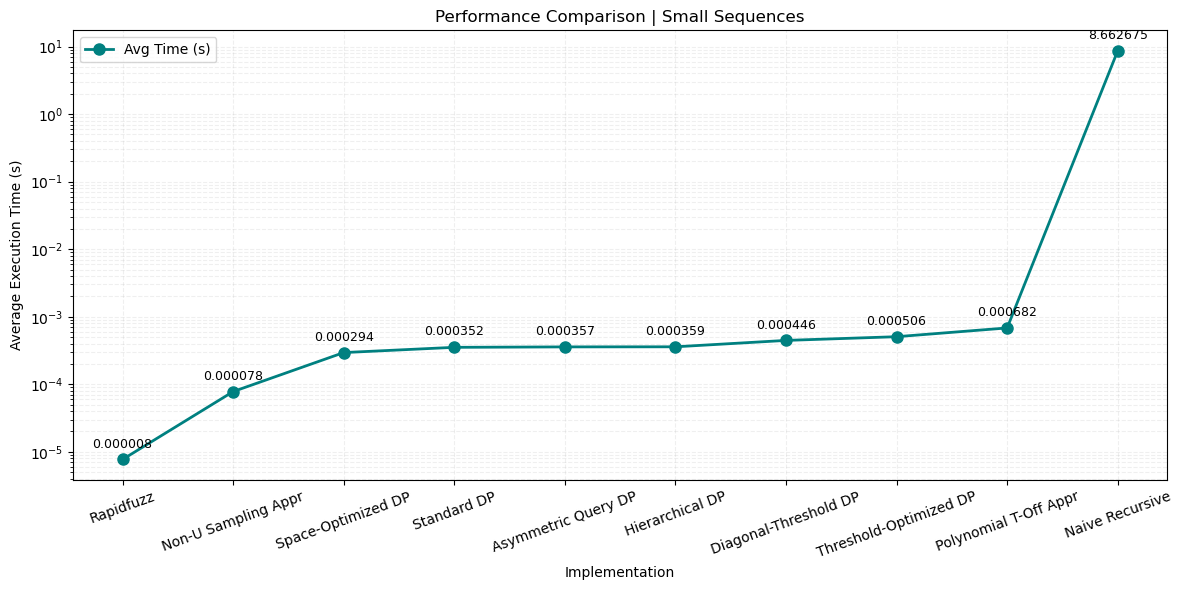

In [42]:
plot_performance(results_small, "Performance Comparison | Small Sequences")

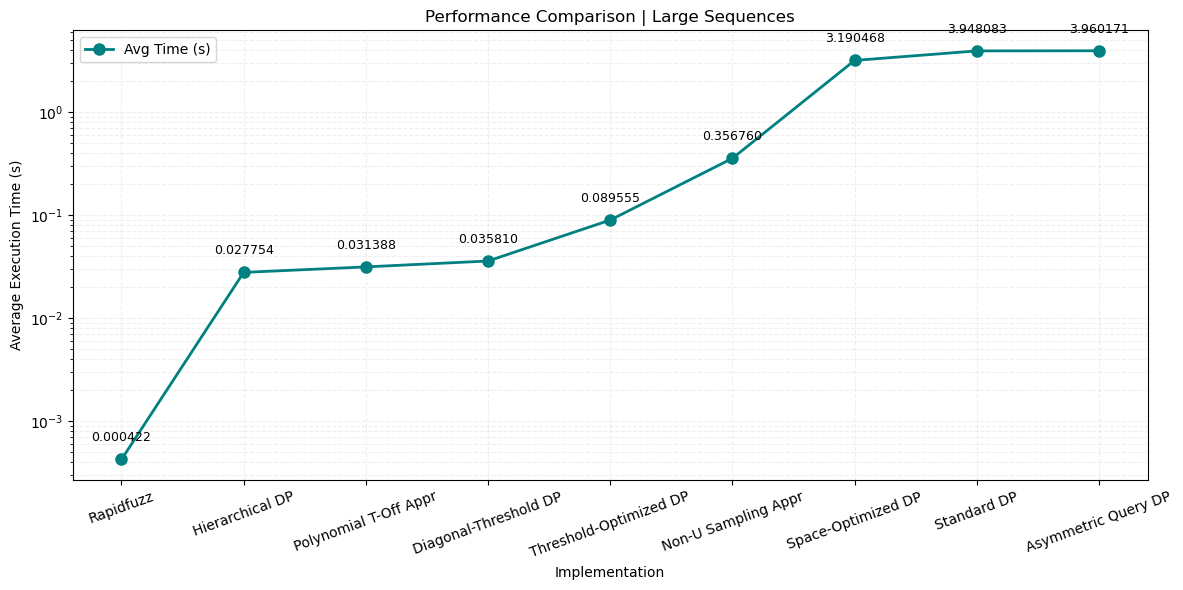

In [43]:
plot_performance(results_large, "Performance Comparison | Large Sequences")

`This plot looks perfect, considering I put in 25+ hours of research, implemented algorithms, optimized them, formatted markdown texts, and so much more for just this notebook. It was worth it, and I’m glad I did it.`

## Thank you, AAILab, for this task. I learned a great deal while working on this project. I also appreciate your attention and time.